# Analysis 1: Top 10 categories by review count

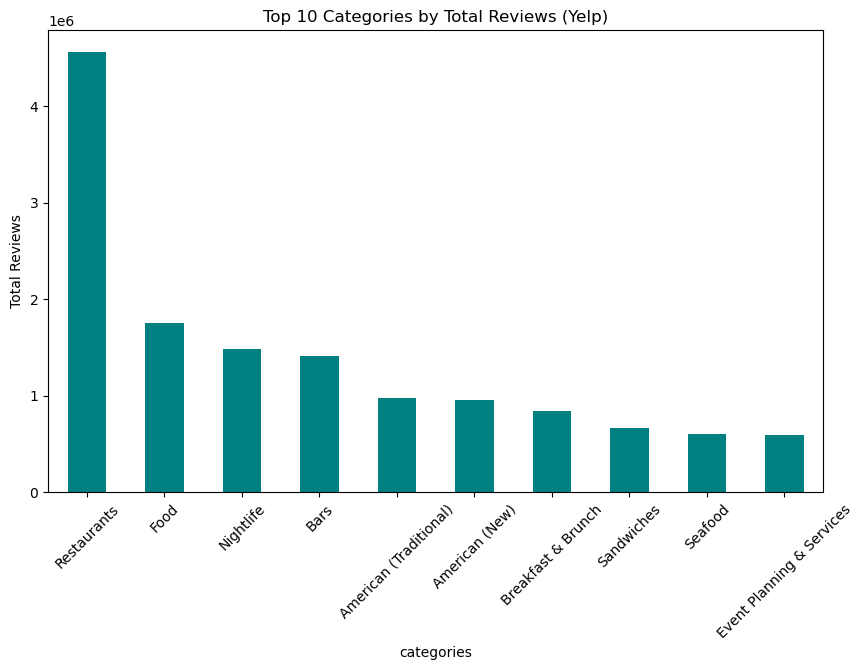

categories
American (New)               3.590782
American (Traditional)       3.399742
Bars                         3.648848
Breakfast & Brunch           3.569562
Event Planning & Services    3.693633
Food                         3.668982
Nightlife                    3.655525
Restaurants                  3.515172
Sandwiches                   3.544227
Seafood                      3.674908
Name: stars, dtype: float64


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

path = "/net/pr2/projects/plgrid/plgglscclass/yelp-dataset/yelp_academic_dataset_business.json"

df = pd.read_json(path, lines=True)

# We're checking the top categories by total review count.
# We split the 'categories' column into individual categories and then sum the 'review_count' for each category.
top_categories = df.assign(categories=df['categories'].str.split(', ')).explode('categories')
category_reviews = top_categories.groupby('categories')['review_count'].sum().sort_values(ascending=False).head(10)

# Bar chart for top 10 categories by review count
plt.figure(figsize=(10,6))
category_reviews.plot(kind='bar', color='teal')
plt.title('Top 10 Categories by Total Reviews (Yelp)')
plt.ylabel('Total Reviews')
plt.xticks(rotation=45)
plt.show()

# Show the average stars for the top categories
print(top_categories[top_categories['categories'].isin(category_reviews.index)].groupby('categories')['stars'].mean())

# Analysis 2: Review count distribution for different star ratings

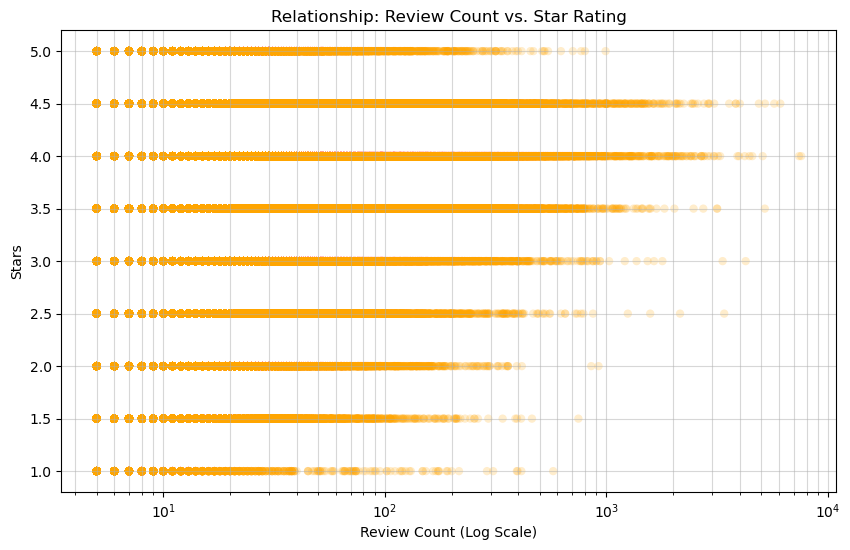

In [15]:
plt.figure(figsize=(10,6))

# Używamy plt.scatter zamiast sns.scatterplot
plt.scatter(df['review_count'], df['stars'], alpha=0.2, color='orange', edgecolors='none')

# Skala logarytmiczna dla osi X
plt.xscale('log')

plt.title('Relationship: Review Count vs. Star Rating')
plt.xlabel('Review Count (Log Scale)')
plt.ylabel('Stars')

# Siatka dla lepszej czytelności przy skali logarytmicznej
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()

# Analysis 3: Average star rating by city (for top 15 cities)

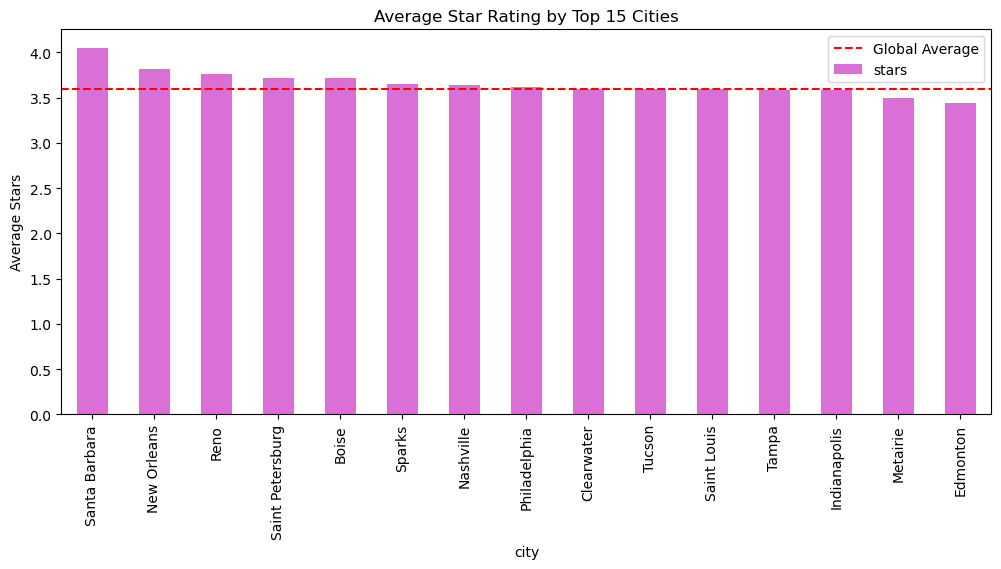

In [16]:
top_cities = df['city'].value_counts().head(15).index
city_stats = df[df['city'].isin(top_cities)].groupby('city')['stars'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
city_stats.plot(kind='bar', color='orchid')
plt.axhline(df['stars'].mean(), color='red', linestyle='--', label='Global Average')
plt.title('Average Star Rating by Top 15 Cities')
plt.ylabel('Average Stars')
plt.legend()
plt.show()

# Analysis 4: Top 10 cities by number of businesses

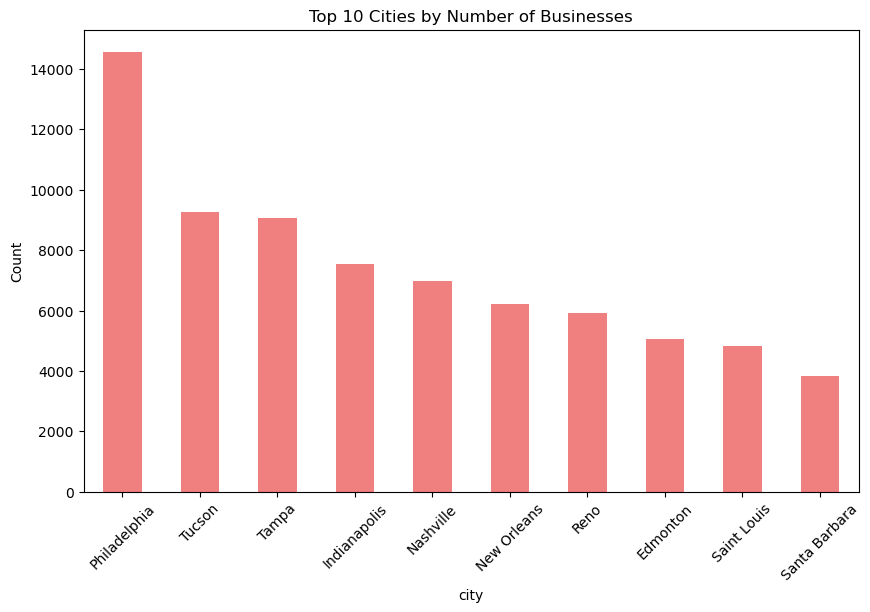

In [17]:
plt.figure(figsize=(10,6))
df['city'].value_counts().head(10).plot(kind='bar', color='lightcoral')
plt.title('Top 10 Cities by Number of Businesses')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()